# Portfolio - CheckPoint 2 (Hierarchical Data Visualization)

Team: Moises' Team

Team members:

* Luis Arturo Michel Perez
* Oscar Martinez Estevez
* Moises Jesus Carrillo Alonso
* Braulio Jesus Perez Tamayo
* Gerardo Hernandez Widman
* Mario David Hernandez Pantoja

## Practice Objective
Develop skills in creating and analyzing hierarchical visualizations using Python, applying different techniques such as Treemaps, Dendrograms, Sunburst Charts, and Circular Treemaps to represent multilevel data structures and understand when to use each type of visualization.

## Activity Description
In this practice, you will work with hierarchical data using specialized Python libraries. You will implement four main types of hierarchical visualizations and conduct a comparative analysis of their advantages and limitations.

Main components:

1. Treemap - World Population Analysis: Create static and interactive treemaps showing population distribution across continents and countries, using size to represent population and color to represent GDP per capita.

2. Dendrogram - Hierarchical Clustering: Perform hierarchical clustering analysis on countries based on population and GDP per capita, visualizing similarities and groupings through dendrograms using the Ward method.

3. Sunburst Chart - Organizational Structure: Visualize a technology company's organizational structure across multiple levels, showing the distribution of employees from main departments down to specific teams.

4. Circular Treemap - Budget Distribution: Represent budget allocation across departments and projects, demonstrating how resources are distributed hierarchically within an organization.

5. Comparative Analysis: Compare different visualization techniques using the same dataset to understand which technique is most appropriate for different analytical scenarios.

# Library imports and configuration

In [26]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
import squarify

import scipy 
import scipy.cluster.hierarchy 
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, set_link_color_palette
import scipy.spatial.distance
from scipy.spatial.distance import pdist

import sklearn 
import sklearn.preprocessing
from sklearn.preprocessing import StandardScaler


## Loading and verifing data

In [2]:
from pathlib import Path

In [11]:
current_dir = Path.cwd()
budget_data_path = current_dir.parent / "data_files" / "checkpoint2" / "budget_data.csv"
empresas_tech_path = current_dir.parent / "data_files" / "checkpoint2" / "empresas_tech.csv"
population_continent_path = current_dir.parent / "data_files" / "checkpoint2" / "gdp_population_and_continent_un_195_countries.csv"

In [12]:
try:
    df = pd.read_csv(budget_data_path)
    print("CSV file loaded successfully!")
    print(df.head())
except FileNotFoundError:
    print(f"Error: File not found at {budget_data_path.resolve()}")
except Exception as e:
    print(f"An error occurred: {e}")

CSV file loaded successfully!
    department               project  budget
0  Engineering  Cloud Infrastructure    2500
1  Engineering   Product Development    3500
2  Engineering              Security    1800
3  Engineering         Data Pipeline    2200
4    Marketing     Digital Campaigns    1500


In [13]:
try:
    df = pd.read_csv(empresas_tech_path)
    print("CSV file loaded successfully!")
    print(df.head())
except FileNotFoundError:
    print(f"Error: File not found at {empresas_tech_path.resolve()}")
except Exception as e:
    print(f"An error occurred: {e}")

CSV file loaded successfully!
        labels  parents  values
0      Company      NaN     500
1  Engineering  Company     180
2      Product  Company      80
3        Sales  Company     120
4   Operations  Company     120


In [14]:
try:
    df = pd.read_csv(population_continent_path)
    print("CSV file loaded successfully!")
    print(df.head())
except FileNotFoundError:
    print(f"Error: File not found at {population_continent_path.resolve()}")
except Exception as e:
    print(f"An error occurred: {e}")

CSV file loaded successfully!
            País     Continente  PIB 2023 (USD corrientes)  \
0  United States  North America               2.772071e+13   
1          China           Asia               1.827036e+13   
2        Germany         Europe               4.525704e+12   
3          Japan           Asia               4.213167e+12   
4          India           Asia               3.638489e+12   

   Poblacion Total 2023  
0          3.368062e+08  
1          1.410710e+09  
2          8.390192e+07  
3          1.245166e+08  
4          1.438070e+09  


## Extra exploration of our data cleaned

In [15]:
budget_data_df = pd.read_csv(budget_data_path)
empresas_tech_df = pd.read_csv(empresas_tech_path)
population_continent_df = pd.read_csv(population_continent_path)

In [20]:
budget_data_df.info()
budget_data_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   department  13 non-null     object
 1   project     13 non-null     object
 2   budget      13 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 444.0+ bytes


,budget
count,13.000000
mean,1538.461538
std,836.200197
min,600.000000
25%,900.000000
50%,1200.000000
75%,2000.000000
max,3500.000000


In [19]:
empresas_tech_df.info()
empresas_tech_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   labels   33 non-null     object
 1   parents  32 non-null     object
 2   values   33 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 924.0+ bytes


,values
count,33.000000
mean,53.333333
std,88.159893
min,12.000000
25%,20.000000
50%,30.000000
75%,40.000000
max,500.000000


In [21]:
population_continent_df.info()
population_continent_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   País                       195 non-null    object 
 1   Continente                 195 non-null    object 
 2   PIB 2023 (USD corrientes)  190 non-null    float64
 3   Poblacion Total 2023       190 non-null    float64
dtypes: float64(2), object(2)
memory usage: 6.2+ KB


,PIB 2023 (USD corrientes),Poblacion Total 2023
count,1.900000e+02,1.900000e+02
mean,5.455058e+11,4.153436e+07
std,2.478485e+12,1.513215e+08
min,0.000000e+00,9.816000e+03
25%,1.015944e+10,2.128680e+06
50%,3.756483e+10,9.155030e+06
75%,2.656791e+11,3.082060e+07
max,2.772071e+13,1.438070e+09


# Part 1: Static and interactive treemaps

Creating static Treemap...


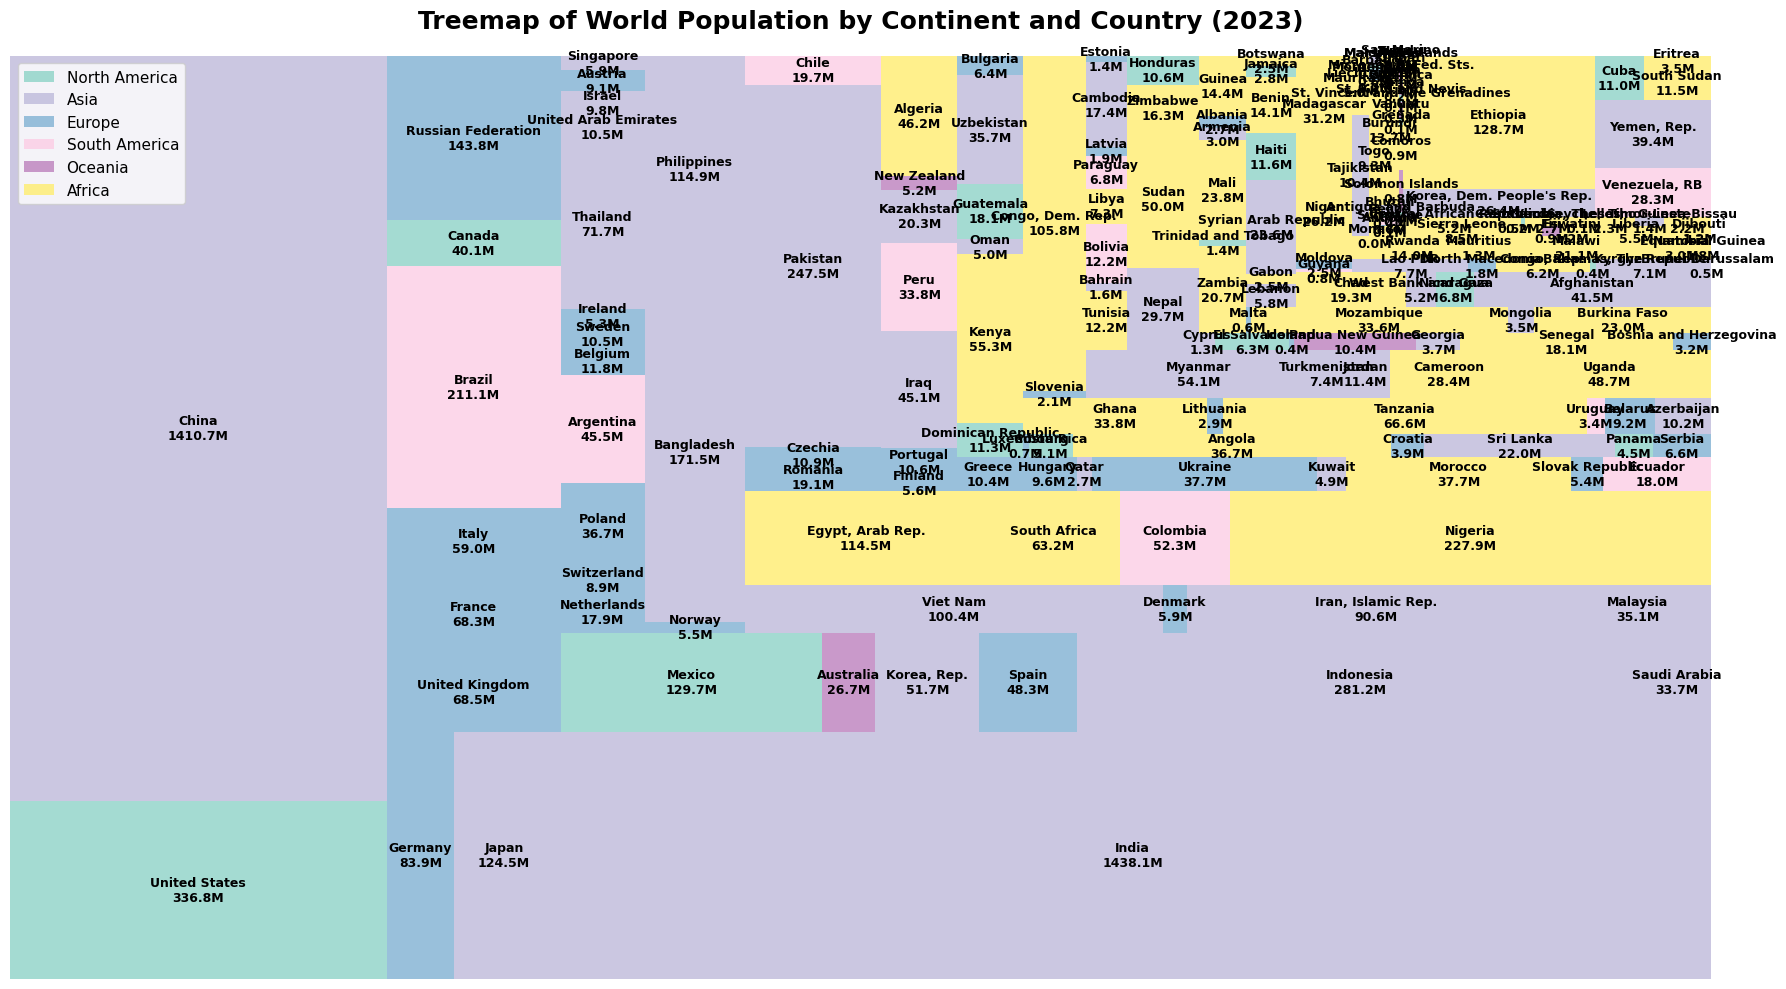

Static Treemap completed!


In [22]:
print("Creating static Treemap...")

# Prepare data
df = population_continent_df.dropna(subset=['Poblacion Total 2023'])
sizes = df['Poblacion Total 2023'].values
labels = [f"{country}\n{pop/1e6:.1f}M" for country, pop in zip(df['País'], df['Poblacion Total 2023'])]

# Colors by continent
continents = df['Continente'].unique()
continent_colors = plt.cm.Set3(np.linspace(0, 1, len(continents)))
color_map = dict(zip(continents, continent_colors))
colors = [color_map[cont] for cont in df['Continente']]

# Create Treemap
fig, ax = plt.subplots(1, figsize=(18, 10))
squarify.plot(
    sizes=sizes,
    label=labels,
    color=colors,
    alpha=0.8,
    text_kwargs={'fontsize': 9, 'weight': 'bold'},
    ax=ax
)

plt.title('Treemap of World Population by Continent and Country (2023)',
          fontsize=18, weight='bold', pad=20)
plt.axis('off')

# Legend
legend_elements = [plt.Rectangle((0, 0), 1, 1, fc=color_map[cont], alpha=0.8, label=cont)
                   for cont in continents]
plt.legend(handles=legend_elements, loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

print("Static Treemap completed!")

In [23]:
print("Creating interactive Treemap with Plotly...")

# Clean and prepare
df_plotly = df.copy()
df_plotly['PIB per capita'] = df_plotly['PIB 2023 (USD corrientes)'] / df_plotly['Poblacion Total 2023']

# Plotly treemap
fig = px.treemap(
    df_plotly,
    path=['Continente', 'País'],
    values='Poblacion Total 2023',
    color='PIB per capita',
    hover_data=['Poblacion Total 2023', 'PIB 2023 (USD corrientes)', 'PIB per capita'],
    color_continuous_scale='RdYlGn',
    title='Interactive World Population Treemap (2023)<br>Size = Population, Color = GDP per Capita'
)

fig.update_traces(textinfo="label+value", textfont_size=11)
fig.update_layout(height=700, width=1000)
fig.show()

print("Interactive Treemap completed!")
print("Click on continents to zoom in.")

Creating interactive Treemap with Plotly...


Interactive Treemap completed!
Click on continents to zoom in.


# Part 2: Dendrogram with hierarchical clustering

Calculating hierarchical clustering...


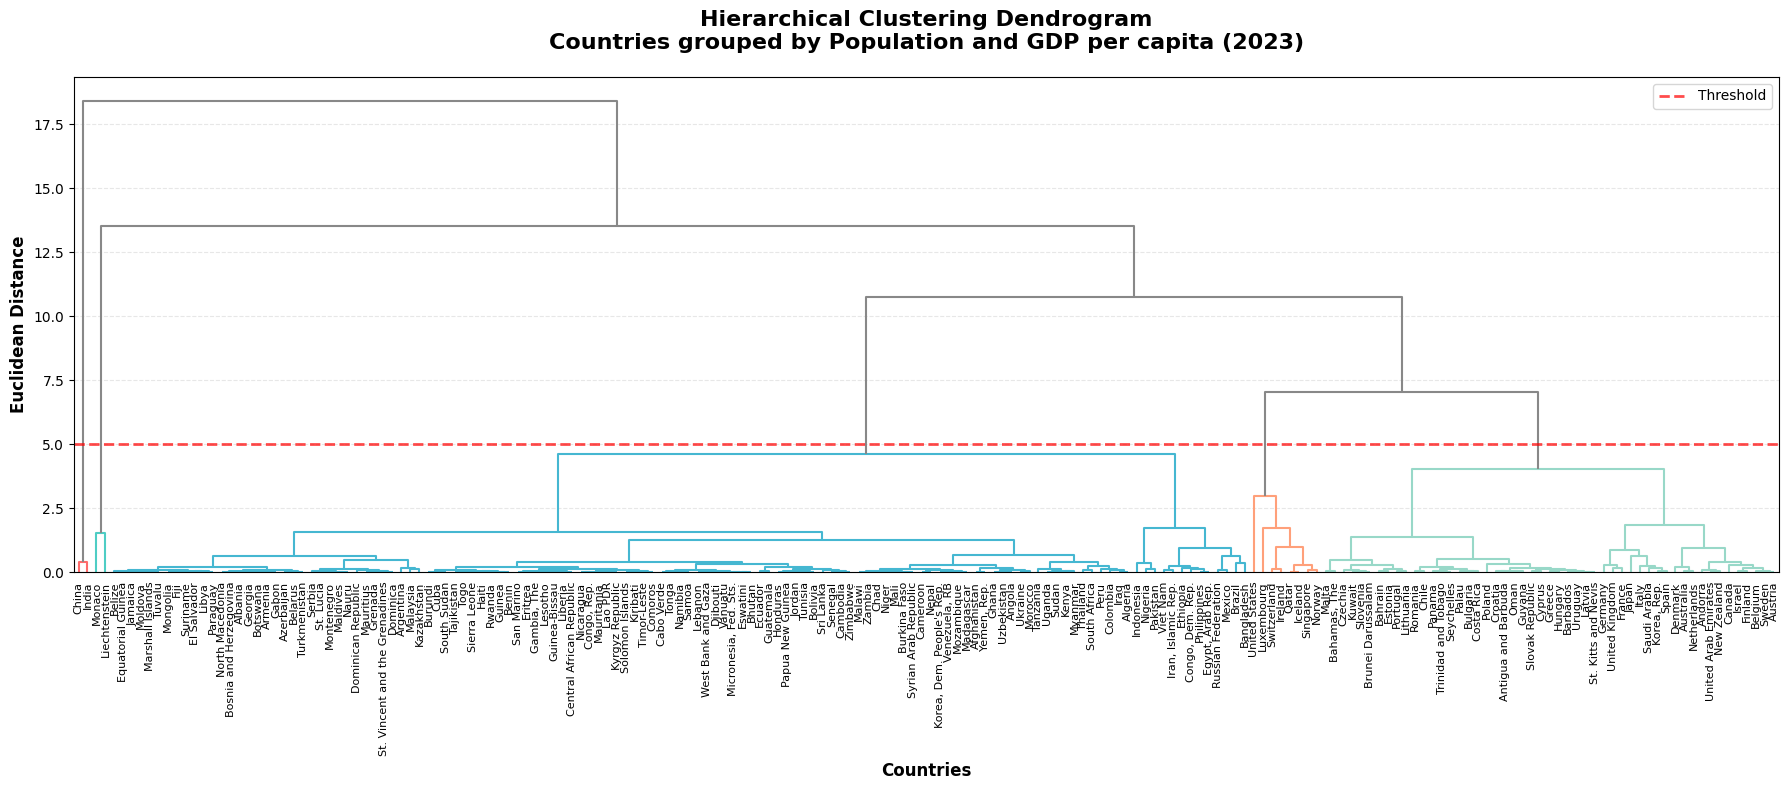

Dendrogram completed successfully!

Number of clusters formed: 5

Countries by cluster:
Cluster 1: China, India
Cluster 2: Monaco, Liechtenstein
Cluster 3: Brazil, Russian Federation, Mexico, Indonesia, Argentina, Thailand, Bangladesh, Philippines, Viet Nam, Iran, Islamic Rep....
Cluster 4: United States, Switzerland, Ireland, Singapore, Norway, Qatar, Luxembourg, Iceland
Cluster 5: Germany, Japan, United Kingdom, France, Italy, Canada, Australia, Korea, Rep., Spain, Saudi Arabia...


In [27]:
print("Calculating hierarchical clustering...")

# Prepare data
df = population_continent_df.dropna(subset=['PIB 2023 (USD corrientes)', 'Poblacion Total 2023']).copy()
df['PIB per capita'] = df['PIB 2023 (USD corrientes)'] / df['Poblacion Total 2023']

# Select features for clustering
features_for_clustering = df[['Poblacion Total 2023', 'PIB per capita']].values

# Normalize data
scaler = StandardScaler()
features_normalized = scaler.fit_transform(features_for_clustering)

# Compute distance matrix and linkage
distances = pdist(features_normalized, metric='euclidean')
linkage_matrix = linkage(distances, method='ward')

# Set threshold for cluster separation
my_threshold = 5  # you can tweak this value for more or fewer clusters

# Plot dendrogram
fig, ax = plt.subplots(figsize=(18, 8))
set_link_color_palette(['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F', '#96CEB4'])

dendro = dendrogram(
    linkage_matrix,
    labels=df['País'].values,
    leaf_font_size=8,
    color_threshold=my_threshold,
    above_threshold_color='#888888',
    ax=ax
)

plt.title('Hierarchical Clustering Dendrogram\nCountries grouped by Population and GDP per capita (2023)',
          fontsize=16, weight='bold', pad=20)
plt.xlabel('Countries', fontsize=12, weight='bold')
plt.ylabel('Euclidean Distance', fontsize=12, weight='bold')
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Threshold line
plt.axhline(y=my_threshold, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Threshold')
plt.legend()

plt.tight_layout()
plt.show()

print("Dendrogram completed successfully!")

# Interpretation and clusters
clusters = fcluster(linkage_matrix, t=my_threshold, criterion='distance')
n_clusters = len(np.unique(clusters))
print(f"\nNumber of clusters formed: {n_clusters}")

# Assign clusters to DataFrame
df['Cluster'] = clusters

print("\nCountries by cluster:")
for i in range(1, n_clusters + 1):
    countries_in_cluster = df.loc[df['Cluster'] == i, 'País'].values
    print(f"Cluster {i}: {', '.join(countries_in_cluster[:10])}{'...' if len(countries_in_cluster) > 10 else ''}")

# Part 3: Sunburst chart for organizational structure

In [31]:
print("Creating Sunburst Chart...")

import plotly.graph_objects as go

# Prepare your DataFrame
df = empresas_tech_df.copy()

# Create the Sunburst Chart
fig = go.Figure(go.Sunburst(
    labels=df['labels'],
    parents=df['parents'],
    values=df['values'],
    branchvalues="total",  # Ensures parent values include children
    marker=dict(
        colors=df['values'],
        colorscale='Viridis',
        cmid=df['values'].mean(),
        line=dict(color='white', width=2)
    ),
    hovertemplate='<b>%{label}</b><br>Value: %{value}<br>Percentage: %{percentParent:.1%}<extra></extra>',
    textfont=dict(size=11)
))

# Layout configuration
fig.update_layout(
    title='Organizational Structure - Tech Company<br>Sunburst Chart',
    width=900,
    height=900,
    font=dict(size=12)
)

# Show chart
fig.show()

print("Sunburst chart completed!")
print("Tip: Click on any segment to zoom in.")


Creating Sunburst Chart...


Sunburst chart completed!
Tip: Click on any segment to zoom in.


# Part 4: Circular treemap for budget distribution

# Part 5: Comparison of visualization techniques


# Final quantitative analysis and insights